# Linear Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import pickle


## Definición del problema

>### Predecir el coste del seguro médico de una persona
>La importante compañía de seguros 4Geeks Insurance S.L. quiere calcular, en función de datos los fisiológicos de sus clientes, cuál va a ser la prima (coste) que debe asumir cada uno de ellos. Para ello, ha reunido a un equipo completo de médicos y en función de datos de otras compañías y un estudio particular han logrado reunir un conjunto de datos para entrenar un modelo predictivo.


## Recopilación de datos

In [5]:
df = pd.read_csv('/workspaces/adamcn10-intro-ml/data/raw/medical_insurance_cost.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Análisis Descriptivo

In [6]:
df.shape

(1338, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


##### Observaciones- Conclusiones
>- Vemos que es un set de datos de 1338 filas y 7 columnas sin valores nulos en ninguna de ellas.
>- De los datos que tenemos 3 son categóricos ('sex', 'smoker' y 'region') y el resto númericos ('age', 'bmi', 'children' y la variable objetivo 'charges')

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [10]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

##### Observaciones- Conclusiones
>- Vemos que la variable objetivo tiene practicamente un valor diferente para cada entrada menos uno, se podría tratar de una fila duplicada.
>- Bmi es la otra con más valores distintos, el resto de variables tienen unca cantidad lógica o reducida de valores.

## Limpieza de Datos

### Eliminación de duplicados

In [11]:
df.duplicated().sum()

np.int64(1)

>Vemos que hay un valor duplicado y por lo visto antes, solo podía haber una fila duplicada por la cantidad de primas diferentes que veiamos.
>Procederemos a eliminar esta fila duplicada con drop_duplicates

In [12]:
df.drop_duplicates(inplace=True)
df.shape

(1337, 7)

>Ahora el dataframe consta de 1337 filas diferentes y 7 columnas

## Eliminación de la información irrelevante

>La unica información que podría llegar a ser irrelevante es la de la columna 'region', pero dado que esto no es seguro y si que podría influir dejaré la eliminación de esta como un comentario y no se ejecutará.

In [ ]:
#df.drop('region', inplace=True)

## Análisis de Variables

## Análisis de Variables Univariable

### Análisis de Variables Univariable Categórica

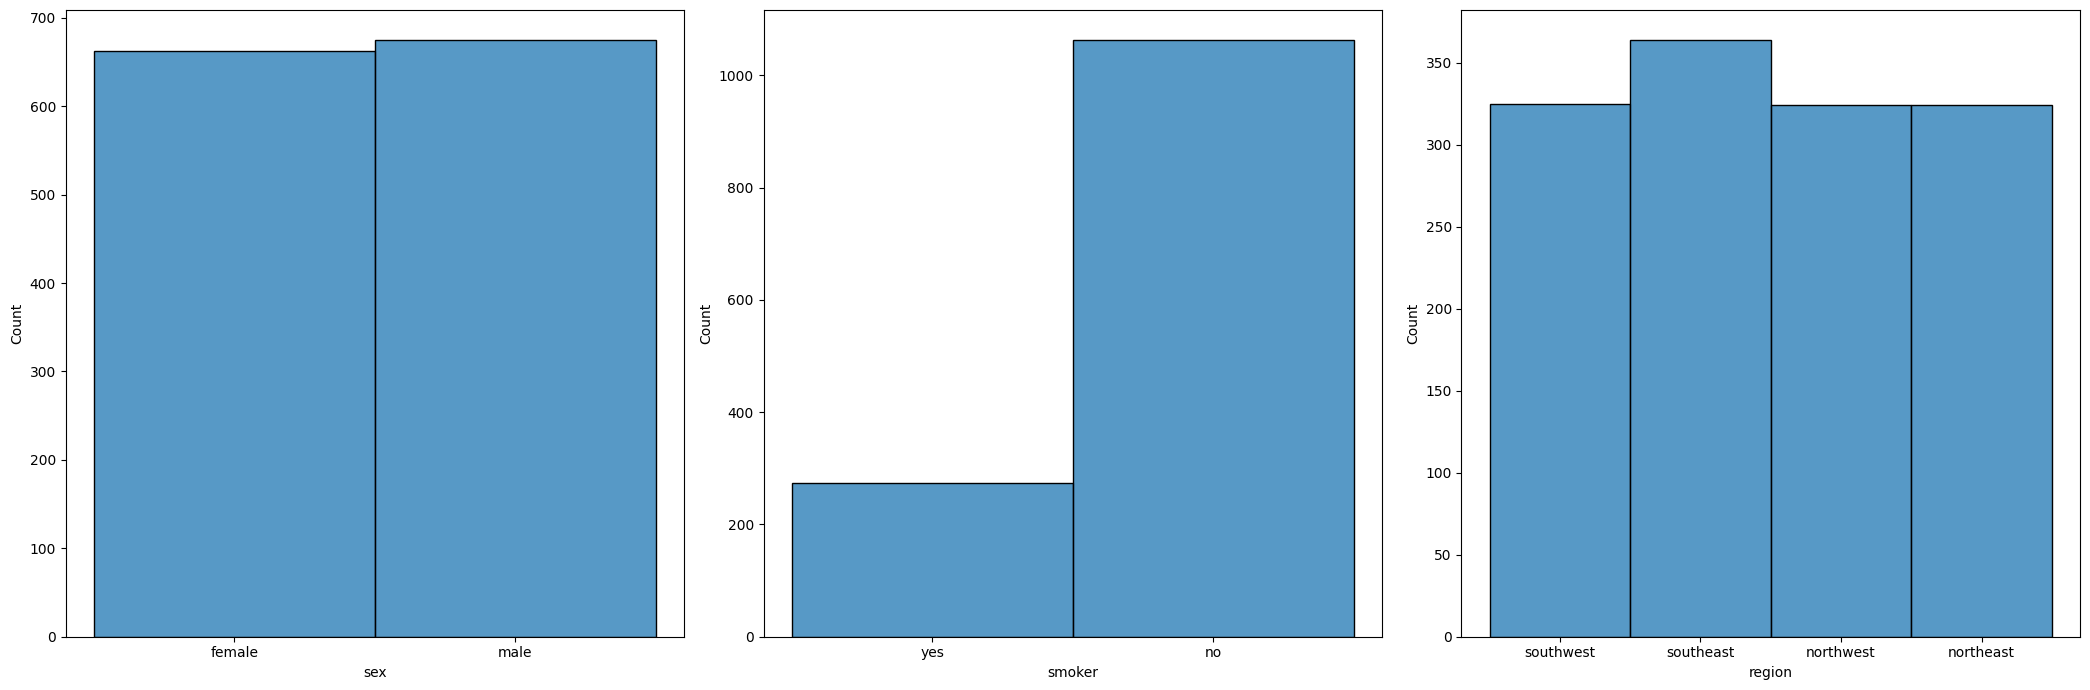

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(21,7))
sns.histplot(ax=axs[0], data=df, x="sex")
sns.histplot(ax=axs[1], data=df, x="smoker")
sns.histplot(ax=axs[2], data=df, x="region")
plt.tight_layout()
plt.show()

##### Observaciones - Conclusiones
> Vemos que los datos de sexo y región estan repartidos de manera bastante equitativa, en cambio, el hecho de fumar o no, hay mucha más gente no fumadora que sí.

### Análisis de Variables Univariable Numérico

<function matplotlib.pyplot.show(close=None, block=None)>

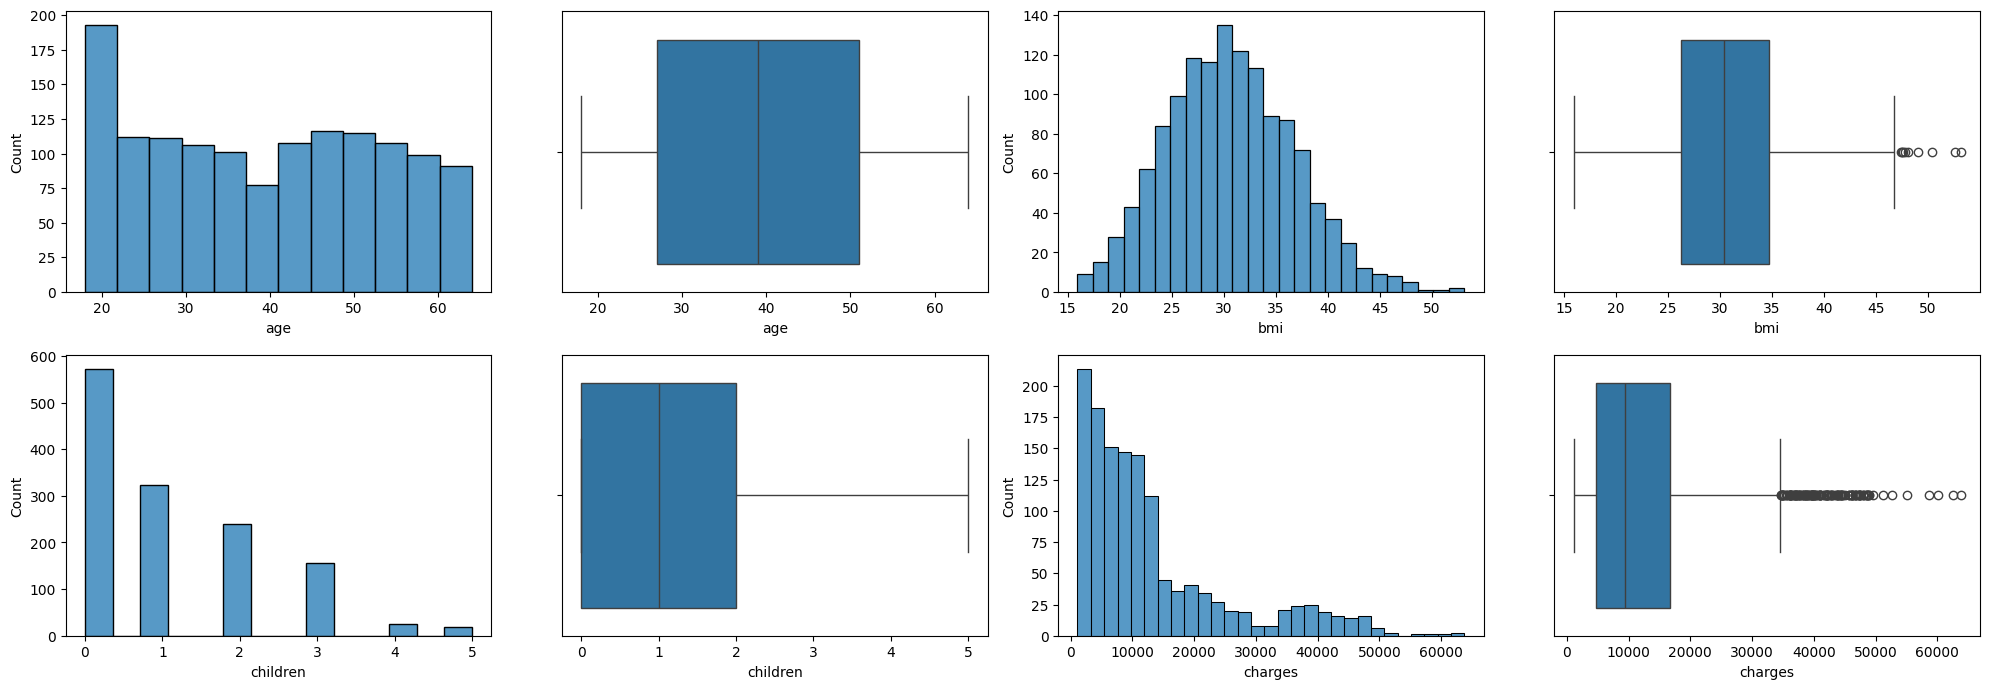

In [15]:
fig, axis = plt.subplots(2, 4, figsize=(20, 7))

sns.histplot(ax=axis[0, 0], data=df, x="age")
sns.boxplot(ax=axis[0, 1], data=df, x="age")
sns.histplot(ax=axis[0, 2], data=df, x="bmi")
sns.boxplot(ax=axis[0, 3], data=df, x="bmi")
sns.histplot(ax=axis[1, 0], data=df, x="children")
sns.boxplot(ax=axis[1, 1], data=df, x="children")
sns.histplot(ax=axis[1, 2], data=df, x="charges")
sns.boxplot(ax=axis[1, 3], data=df, x="charges")

plt.tight_layout()
plt.show